In [2]:
import glob
import os
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd

import ldparser
from ldparser import ldData

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

ModuleNotFoundError: No module named 'numpy'

In [ ]:
ld_data = glob.glob("data/*.ld")
print(f"[Info] {len(ld_data)} Telemetriedateien im Ordner gefunden.")

# Mapping der relevanten Kanäle zu den Spaltennamen im DataFrame
channel_tuple_mapping = {
    'Suspension Travel FL': 's_damperFL',
    'Brake Bias': 'percent_brake_balance',
    'Brake Temp FL': 't_brakeFL',
    'Wheel Angular Speed FL': 'v_tyreFL'
}

[Info] 5 Telemetriedateien im Ordner gefunden.


# =========================================================
# PHASE 1: AUTOMATISIERTE DATEN-AGGREGATION
# =========================================================

In [ ]:
master_feature_liste = []

for ld_file in ld_data:
    timestamp_in_seconds = []
    ldx_file = ld_file.replace('.ld', '.ldx')

    # LDX-Datei einlesen und Zeitstempel der Beacons extrahieren
    try: 
        ldx_file_tree = ET.parse(ldx_file)
        ldx_file_root = ldx_file_tree.getroot()

        for beacon in ldx_file_root.findall('.//MarkerGroup[@Name="Beacons"]/Marker'):
            time_node = beacon.get('Time')

            if time_node is not None:
                time_node_in_seconds = float(time_node) / 1000000.0
                timestamp_in_seconds.append(time_node_in_seconds)
    except Exception as e:
        print(f"\n{e}")

    # LD-Datei einlesen und relevante Kanäle extrahieren
    telemetry_tuple = ldData.fromfile(ld_file)
    channel_data = {}
    for ld_name, htf_name in channel_tuple_mapping.items():
        
        if ld_name in telemetry_tuple:
            channel_object = telemetry_tuple[ld_name]
            channel_data[htf_name] = pd.Series(data=channel_object.data, index=np.arange(len(channel_object.data)) / getattr(channel_object, 'freq'))

            df_telemetry = pd.DataFrame(channel_data)

        else:
            print(f"\n{e}")
    

    for i in range(len(timestamp_in_seconds) - 1):
        # Zeit der Fahrer pro Rundenabschnitt extrahieren
        start_time = timestamp_in_seconds[i]
        end_time = timestamp_in_seconds[i + 1]
        
        curve_data = df_telemetry[(df_telemetry.index >= start_time) & (df_telemetry.index < end_time)]
        if curve_data.empty:
            continue

        # Fahrer-ID aus dem Dateinamen extrahieren
        file_name = os.path.basename(ld_file)
        data_name_parted = file_name.split('_&_')
        
        if len(data_name_parted) >= 3:
            driver_id = data_name_parted[2]
        else:
            driver_id = file_name
            
        feature = {
            'Fahrer_ID': driver_id,
            'Segment_Nummer': i + 1,
            's_damperFL_max': curve_data['s_damperFL'].max(),           
            's_damperFL_var': curve_data['s_damperFL'].var(),           
            'percent_brake_balance_mean': curve_data['percent_brake_balance'].mean(), 
            't_brakeFL_max': curve_data['t_brakeFL'].max(),             
            'v_tyreFL_mean': curve_data['v_tyreFL'].mean()
        }
        master_feature_liste.append(feature)

df_master_ml = pd.DataFrame(master_feature_liste)
display(df_master_ml)
    

,Fahrer_ID,Segment_Nummer,s_damperFL_max,s_damperFL_var,percent_brake_balance_mean,t_brakeFL_max,v_tyreFL_mean
0,THTH312,1,114.614000,125.730297,54.000002,26.0,78.728081
1,THTH312,2,118.406000,99.654252,54.000002,26.0,65.150724
2,THTH312,3,114.294000,106.110113,54.000002,26.0,74.061532
3,THTH312,4,113.084000,125.396153,54.000002,26.0,78.693141
4,THTH312,5,113.676000,121.847042,54.000002,26.0,73.625121
5,THTH312,6,106.464000,129.068844,54.000002,26.0,80.377248
6,ALAD201,1,93.808333,53.107145,54.000002,26.0,65.151012
7,ALAD201,2,105.761667,85.369808,54.000002,26.0,68.343661
8,ALAD201,3,108.960000,92.803041,54.000002,26.0,66.787381
9,ALAD201,4,83.383333,76.818705,54.000002,26.0,79.824516


# =========================================================
# PHASE 2: PENG PENG PEW PEW
# =========================================================

Fahrer_ID,ALAD201,NIMB230,RINE150,SOMD122,THTH312
Fahrstil_Cluster_ID,,,,,
0,0,0,1,5,0
1,0,3,5,1,0
2,4,0,0,0,6
3,2,0,0,0,0
4,0,3,0,0,0



Prozentuale Verteilung der Fahrstile je Fahrer:


Fahrstil_Cluster_ID,0,1,2,3,4
Fahrer_ID,,,,,
ALAD201,0.0%,0.0%,66.7%,33.3%,0.0%
NIMB230,0.0%,50.0%,0.0%,0.0%,50.0%
RINE150,16.7%,83.3%,0.0%,0.0%,0.0%
SOMD122,83.3%,16.7%,0.0%,0.0%,0.0%
THTH312,0.0%,0.0%,100.0%,0.0%,0.0%



[V] Zeichne multidimensionalen Cluster-Plot...


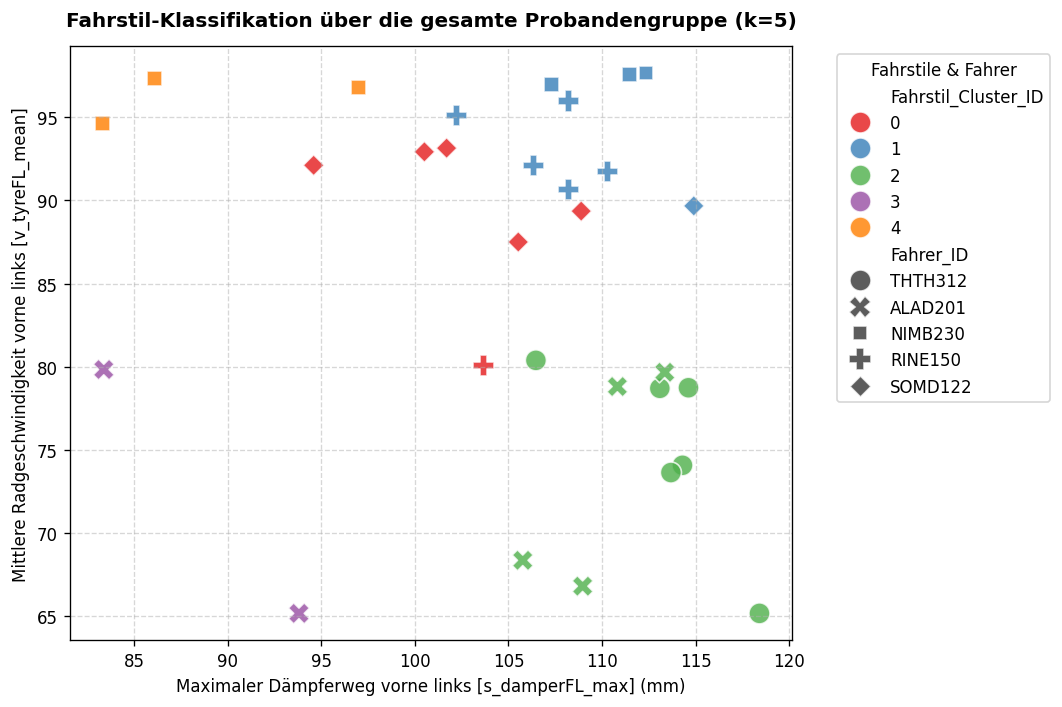

In [ ]:
try: 
    x_clustering = df_master_ml.drop(columns=['Fahrer_ID', 'Segment_Nummer'])

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_clustering)

    # AI AI AI AI AI 
    cluster_numbers = 5
    kmeans = KMeans(n_clusters=cluster_numbers, random_state=42, n_init=10)

    # Der lernt was pff
    df_master_ml['Fahrstil_Cluster_ID'] = kmeans.fit_predict(x_scaled)

    cross_table = pd.crosstab(df_master_ml['Fahrstil_Cluster_ID'], df_master_ml['Fahrer_ID'])
    display(cross_table)
    
    # Prozentuale Verteilung pro Fahrer
    print("\nProzentuale Verteilung der Fahrstile je Fahrer:")
    cross_table_pct = pd.crosstab(df_master_ml['Fahrer_ID'], df_master_ml['Fahrstil_Cluster_ID'], normalize='index') * 100
    display(cross_table_pct.round(1).map(lambda x: f"{x}%"))

    # Diagramm
    plt.figure(figsize=(9, 6), dpi=120)
    sns.scatterplot(
        data=df_master_ml,
        x='s_damperFL_max',
        y='v_tyreFL_mean',
        hue='Fahrstil_Cluster_ID',
        style='Fahrer_ID',
        palette='Set1',
        s=160,
        alpha=0.8
    )
    
    plt.title(f"Fahrstil-Klassifikation über die gesamte Probandengruppe (k={cluster_numbers})", fontsize=12, fontweight='bold', pad=12)
    plt.xlabel("Maximaler Dämpferweg vorne links [s_damperFL_max] (mm)")
    plt.ylabel("Mittlere Radgeschwindigkeit vorne links [v_tyreFL_mean]")
    plt.legend(title="Fahrstile & Fahrer", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Kritischer Fehler in der AI-Sektion: {e}")
    print("Bitte alleinerziehende Bussinesswoman um Hilfe bei der Fehlersuche.")

# =========================================================
# PHASE 3: EVA
# =========================================================

In [ ]:
try:
    eva_data = glob.glob("data/evaluation/*.ld")
except Exception as e:
    print({e})

_IncompleteInputError: incomplete input (3760671423.py, line 1)